<h2>Solving ILPs using Branch and Bound Algorithm</h2>

We will now present how the branch-and-bound algorithm for solving integer linear programs works. Branch-and-Bound is an important and practical algorithm for solving ILPs. Together with a lot of other approaches such as cutting planes and lift and project methods, it forms the basis for how commercial solvers approach solving ILPs.

We will describe a simple branch-and-bound algorithm here but note that a lot of key implementation details will be left out: they are covered in a more detailed course on the topic of linear programming/combinatorial optimization.

Note - <u> if the LP relaxation yields an integer optimal solution, then it has to also be an optimal solution for the ILP</u>

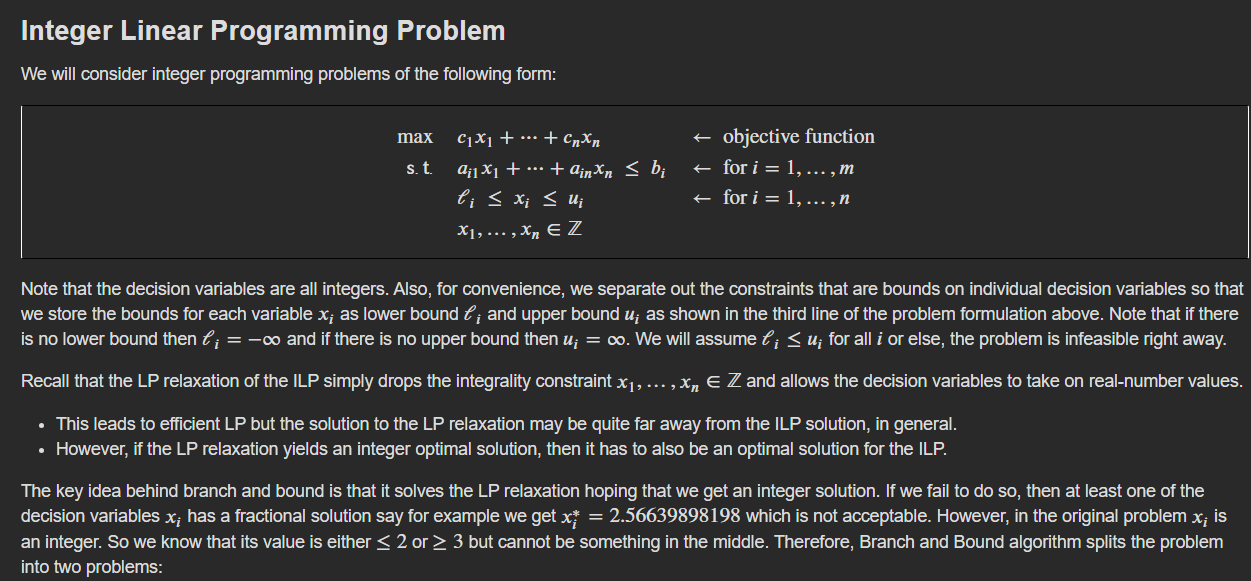

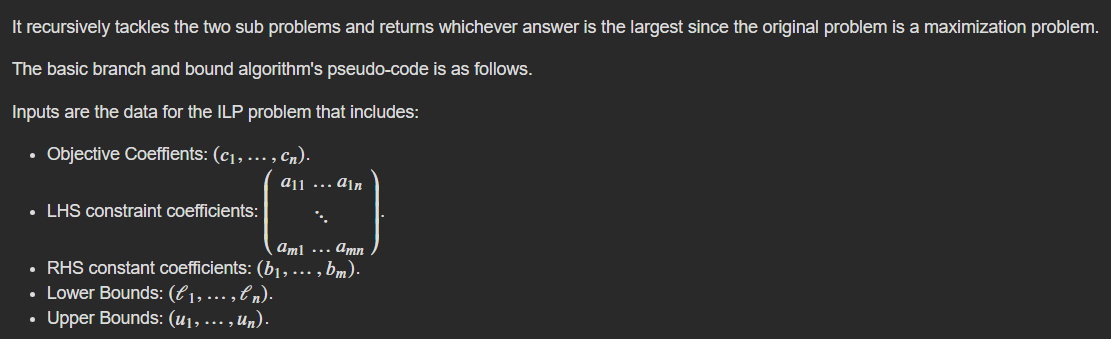
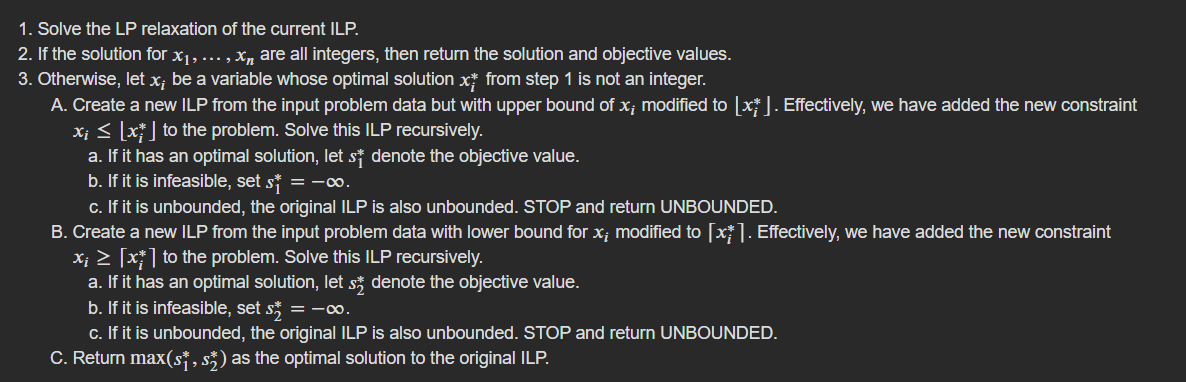

In [1]:
class Stats:
    def __init__(self):
        self.max_depth = 0
        self.num_lps = 0
        self.num_infeas = 0
        
    def print(self):
        print('Statistics')
        print('---------------------------------')
        print(f'Number of LPs Solved: {self.num_lps}')
        print(f'Number of infeasible LPs: {self.num_infeas}')
        print(f'Max. Recursion Depth: {self.max_depth}')
        print('---------------------------------')

In [3]:
from pulp import *
from math import floor, ceil

# Given a list of numbers, find all indices in the list that correspond to fractional numbers.
# we use the function is_fractional to define what it means to be "fractional" -- we have to 
# account for floating point errors in this criterion
def find_all_fractional_indices(sols):
    n = len(sols)
    def is_fractional(f):
        epsilon = 0.001 # this is the precision to which we check whether something is an integer
        return  epsilon <= (f - floor(f)) <= 1-epsilon
    return [j for j in range(n) if is_fractional(sols[j]) ]

# This is the main function. 
# stats keeps track of statistics of number of LPs solved, infeasible and max. depth of recursion.
def branch_and_bound_solve(c, A, b, lb, ub, stats, depth=1, debug=True):
    n = len(c)
    m = len(A)
    assert all( len(ai) == n for ai in A), 'All rows in A must have same length'
    assert len(b) == m
    assert len(lb) == n
    assert len(ub) == n
    ## This function is just for pretty printing the tabs
    def indent():
        for _ in range(depth-1):
            print('|  ', end='')
        print(u'\u21B3', end='')
        
    if any(lb[i] > ub[i] for i in range(n)): # if any lower bound is greater than upper bound, problem is infeasible, BAIL
        if debug:
            indent()
            print('Infeasibility detected due to lb[i]> ub[i].')
        return (-float('inf'), None)
   
    # Record statistics
    if depth > stats.max_depth:
        stats.max_depth = depth
    stats.num_lps = stats.num_lps + 1
    ## 1. PART  1: Setup and Solve the LP Relaxation
    # setup and solve the LP
    prob = LpProblem('b_and_b', LpMaximize) # create the problem
    # declare all the variables, set the upper and lower bound here
    # Note: variables are set to "Continuous" since we are solving the LP relaxation
    dvars = [LpVariable(f'x{i}', lowBound=lb[i], upBound=ub[i],cat='Continuous') for i in range(n)]
    # add the objective function -- we already set it to maximize
    prob += lpSum([ci*xi for (ci,xi) in zip(c, dvars)])
    # add the constraints for each row
    for (ai, bi) in zip(A,b):
        prob += lpSum([ aij*xj for (aij,xj) in zip(ai, dvars)]) <= bi
    #Let's solve the problem but supress the output
    status = prob.solve(apis.PULP_CBC_CMD(mip=False, msg=False))
    # Check the problem status
    if status == constants.LpStatusInfeasible: # infeasible?
        if debug:
            indent()
            print('Infeasible Problem: returning negative infinity')
        stats.num_infeas = stats.num_infeas + 1
        return (-float('inf'), None) # return objective value of -infinity
    elif status == constants.LpStatusUnbounded: # unbounded
        if debug: 
            indent()
            print('Unbounded Problem: returning positive infinity')
        return (float('inf'), None) # return objective value of +infinity
    else: # optimal?
        assert status == LpStatusOptimal, 'Problem results in undefined status -- cannot continue'
        sols = [x.varValue for x in dvars] # extract the solutions for each decision variable
        obj_value = sum([ci*xi for (ci, xi) in zip(c, sols)]) # compute objective value
        if debug:
            indent()
            print(f'Obtained solution: {sols} with objective {obj_value}')
        ## PART 2: Branch and Bound Solve
        # check if the solution is integral
        jList = find_all_fractional_indices(sols)
        if len(jList) == 0: # no fractional values 
            if debug:
                indent()
                print('All variables are integral in optimal solution.')
                indent()
                print(f'Returning solution: {sols} with objective {obj_value}')
            return (obj_value, sols) # done
        else:
            ## This is the part where we branch
            split_var = jList[0]
            assert 0 <= split_var < n
            if debug:
                indent()
                print(f'Splitting variable : {split_var} which has a current solution {sols[split_var]}')
            # adjust the upper bound 
            tmp = ub[split_var]
            ub[split_var] = floor(sols[split_var])
            if debug: 
                indent()
                print(f'Branch #1: Adding x{split_var} <= {ub[split_var]}')
            (obj1,sols1) = branch_and_bound_solve(c, A, b, lb, ub, stats, depth+1, debug)
            if obj1 == float('inf'):
                return (obj1, sols1)
            ub[split_var] = tmp
            # adjust the lower bound
            tmp = lb[split_var]
            lb[split_var] = ceil(sols[split_var])
            if debug: 
                indent()
                print(f'Branch #2: Adding x{split_var} >= {lb[split_var]}')
            (obj2, sols2) = branch_and_bound_solve(c, A, b, lb, ub, stats, depth+1, debug)
            lb[split_var] = tmp
            if obj2 == float('inf'): # unbounded 
                return (obj2, sols2)
            # compare solutions and return
            if obj1 < obj2: # which solution is larger?
                if debug:
                    indent()
                    print(f'Returning solution: {sols2} with objective {obj2}')
                return (obj2, sols2)
            else:
                if debug:
                    indent()
                    print(f'Returning solution: {sols1} with objective {obj1}')
                return (obj1, sols1)
    

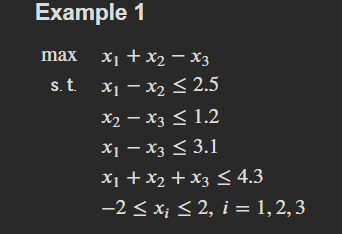

In [4]:
# Let's test it
c = [1, 1, -1]
A = [[1, -1, 0], [0, 1, -1], [1, 0, -1], [1, 1, 1]]
b = [2.5, 1.2, 3.1, 4.3]
lb = [-2, -2, -2]
ub = [2, 2, 2]
stats = Stats()
branch_and_bound_solve(c, A, b, lb, ub, stats)
stats.print()

↳Obtained solution: [2.0, 0.1, -1.1] with objective 3.2
↳Splitting variable : 1 which has a current solution 0.1
↳Branch #1: Adding x1 <= 0
|  ↳Obtained solution: [1.9, 0.0, -1.2] with objective 3.0999999999999996
|  ↳Splitting variable : 0 which has a current solution 1.9
|  ↳Branch #1: Adding x0 <= 1
|  |  ↳Obtained solution: [1.0, -0.8, -2.0] with objective 2.2
|  |  ↳Splitting variable : 1 which has a current solution -0.8
|  |  ↳Branch #1: Adding x1 <= -1
|  |  |  ↳Obtained solution: [1.0, -1.0, -2.0] with objective 2.0
|  |  |  ↳All variables are integral in optimal solution.
|  |  |  ↳Returning solution: [1.0, -1.0, -2.0] with objective 2.0
|  |  ↳Branch #2: Adding x1 >= 0
|  |  |  ↳Obtained solution: [1.0, 0.0, -1.2] with objective 2.2
|  |  |  ↳Splitting variable : 2 which has a current solution -1.2
|  |  |  ↳Branch #1: Adding x2 <= -2
|  |  |  |  ↳Infeasible Problem: returning negative infinity
|  |  |  ↳Branch #2: Adding x2 >= -1
|  |  |  |  ↳Obtained solution: [1.0, 0.0, -

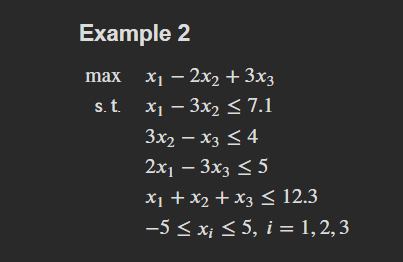

In [5]:
# Let's test it

c = [1, -2, 3]
A = [[1, -3, 0], [0, 3, -1], [2, 0, -3], [1, 1, 1]]
b = [7.1, 4, 5, 12.3]
lb = [-5, -5, -5]
ub = [5, 5, 5]
stats = Stats()
branch_and_bound_solve(c, A, b, lb, ub, stats)
stats.print()

↳Obtained solution: [5.0, -0.7, 5.0] with objective 21.4
↳Splitting variable : 1 which has a current solution -0.7
↳Branch #1: Adding x1 <= -1
|  ↳Obtained solution: [4.1, -1.0, 5.0] with objective 21.1
|  ↳Splitting variable : 0 which has a current solution 4.1
|  ↳Branch #1: Adding x0 <= 4
|  |  ↳Obtained solution: [4.0, -1.0333333, 5.0] with objective 21.0666666
|  |  ↳Splitting variable : 1 which has a current solution -1.0333333
|  |  ↳Branch #1: Adding x1 <= -2
|  |  |  ↳Obtained solution: [1.1, -2.0, 5.0] with objective 20.1
|  |  |  ↳Splitting variable : 0 which has a current solution 1.1
|  |  |  ↳Branch #1: Adding x0 <= 1
|  |  |  |  ↳Obtained solution: [1.0, -2.0333333, 5.0] with objective 20.066666599999998
|  |  |  |  ↳Splitting variable : 1 which has a current solution -2.0333333
|  |  |  |  ↳Branch #1: Adding x1 <= -3
|  |  |  |  |  ↳Obtained solution: [-1.9, -3.0, 5.0] with objective 19.1
|  |  |  |  |  ↳Splitting variable : 0 which has a current solution -1.9
|  |  |  

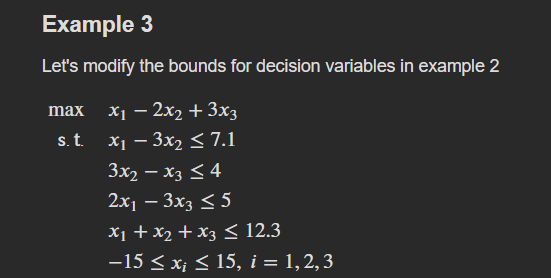

In [6]:
# Let's test it

c = [1, -2, 3]
A = [[1, -3, 0], [0, 3, -1], [2, 0, -3], [1, 1, 1]]
b = [7.1, 4, 5, 12.3]
lb = [-15, -15, -15]
ub = [15, 15, 15]
stats = Stats()
branch_and_bound_solve(c, A, b, lb, ub, stats)
stats.print()

↳Obtained solution: [-0.25, -2.45, 15.0] with objective 49.65
↳Splitting variable : 0 which has a current solution -0.25
↳Branch #1: Adding x0 <= -1
|  ↳Obtained solution: [-1.0, -2.7, 15.0] with objective 49.4
|  ↳Splitting variable : 1 which has a current solution -2.7
|  ↳Branch #1: Adding x1 <= -3
|  |  ↳Obtained solution: [-1.9, -3.0, 15.0] with objective 49.1
|  |  ↳Splitting variable : 0 which has a current solution -1.9
|  |  ↳Branch #1: Adding x0 <= -2
|  |  |  ↳Obtained solution: [-2.0, -3.0333333, 15.0] with objective 49.0666666
|  |  |  ↳Splitting variable : 1 which has a current solution -3.0333333
|  |  |  ↳Branch #1: Adding x1 <= -4
|  |  |  |  ↳Obtained solution: [-4.9, -4.0, 15.0] with objective 48.1
|  |  |  |  ↳Splitting variable : 0 which has a current solution -4.9
|  |  |  |  ↳Branch #1: Adding x0 <= -5
|  |  |  |  |  ↳Obtained solution: [-5.0, -4.0333333, 15.0] with objective 48.0666666
|  |  |  |  |  ↳Splitting variable : 1 which has a current solution -4.033333

As you may notice, the performance of basic branch and bound even on a very small example is not very promising. We can improve this along many axes. One simple improvement that can be made is to keep track of the "best solution so far".

Pruning
Suppose you are solving a problem using branch-and-bound + discover that you already have discovered an integer solution along some branch with an objective value of +10. Let's say that on another branch, we solve a LP relaxation whose objective value is currently +9. We do not have to explore this branch any further. Because, remember the value of ILP will be <= LP relaxation. Therefore, even if we explored the current branch further, it will not yield a value greater than 9. But we already have a solution that is giving us a value of +10, which is better anyway.

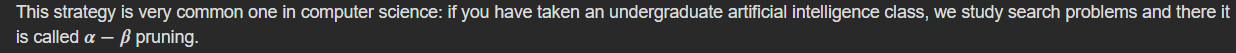

In [8]:
from pulp import *
from math import floor, ceil

# Given a list of numbers, find all indices in the list that correspond to fractional numbers.
# we use the function is_fractional to define what it means to be "fractional" -- we have to 
# account for floating point errors in this criterion
def find_all_fractional_indices(sols):
    n = len(sols)
    def is_fractional(f):
        epsilon = 0.001 # this is the precision to which we check whether something is an integer
        return  epsilon <= (f - floor(f)) <= 1-epsilon
    return [j for j in range(n) if is_fractional(sols[j]) ]


class Solution:
    # a class that will hold the best solution so far
    def __init__(self):
        self.obj_val = -float('inf') # initialize it to -infinity
        self.sol = None
    
    # replace current solution with a new one if it is better
    def replace(self, obj_val, new_sol):
        if obj_val > self.obj_val:
            self.obj_val = obj_val
            self.sol = new_sol
        return
    
# Branch and Bound with Pruning.
# The logic is almost identical to Branch and Bound but we pass around an extra argument
# that tracks the best solution so far
# We pass this argument as a class so that the reference to the class is passed. This allows
# changes made to the best solution so far in one branch to reflect elsewhere in the code.
# If you are unaware of this aspect of python, read about it here: https://www.geeksforgeeks.org/pass-by-reference-vs-value-in-python/#

def branch_and_bound_pruning_solve(c, A, b, lb, ub, best_sol_so_far, stats, depth=1, debug=True):
    n = len(c)
    m = len(A)
    assert all( len(ai) == n for ai in A), 'All rows in A must have same length'
    assert len(b) == m
    assert len(lb) == n
    assert len(ub) == n
    ## This function is just for pretty printing the tabs
    def indent():
        for _ in range(depth-1):
            print('|  ', end='')
        print(u'\u21B3', end='')
    # Check if all lower bounds are <= upper bounds, if not exit
    if any(lb[i] > ub[i] for i in range(n)): # if any lower bound is greater than upper bound, problem is infeasible, BAIL
        if debug:
            indent()
            print('Infeasibility detected due to lb[i]> ub[i].')
        return (-float('inf'), None)
    # record statistics
    if depth > stats.max_depth:
        stats.max_depth = depth
    stats.num_lps = stats.num_lps + 1
    # setup and solve the LP
    prob = LpProblem('b_and_b', LpMaximize) # create the problem
    # declare all the variables, set the upper and lower bound here
    # Note: variables are set to "Continuous" since we are solving the LP relaxation
    dvars = [LpVariable(f'x{i}', lowBound=lb[i], upBound=ub[i],cat='Continuous') for i in range(n)]
    # add the objective function -- we already set it to maximize
    prob += lpSum([ci*xi for (ci,xi) in zip(c, dvars)])
    # add the constraints for each row
    for (ai, bi) in zip(A,b):
        prob += lpSum([ aij*xj for (aij,xj) in zip(ai, dvars)]) <= bi
    #Let's solve the problem but supress the output
    status = prob.solve(apis.PULP_CBC_CMD(mip=False, msg=False))
    # Check the problem status
    if status == constants.LpStatusInfeasible: # infeasible?
        if debug:
            indent()
            print('Infeasible Problem: returning - infinity')
        stats.num_infeas = stats.num_infeas + 1
        return (-float('inf'), None) # return objective value of -infinity
    elif status == constants.LpStatusUnbounded: # unbounded
        if debug: 
            indent()
            print('Unbounded Problem: returning + infinity')
        return (float('inf'), None) # return objective value of +infinity
    else: # optimal?
        assert status == LpStatusOptimal, 'Problem results in undefined status -- cannot continue'
        sols = [x.varValue for x in dvars] # extract the solutions for each decision variable
        obj_value = sum([ci*xi for (ci, xi) in zip(c, sols)]) # compute objective value
        if debug:
            indent()
            print(f'Obtained solution: {sols} with objective {obj_value}')
        # is this objective less than the best so far?
        if obj_value < best_sol_so_far.obj_val: # if it is , then we do not need to go any further
            if debug:
                indent()
                print(f'Pruned solution: we already have an integer solution with objective {best_sol_so_far.obj_val}')
            return (-float('inf'), None) # it does not matter that we return a fake solution here since this will never beat the best solution so far.
 
        # check if the solution is integral
        jList = find_all_fractional_indices(sols)
        if len(jList) == 0: # no fractional values 
            if debug:
                indent()
                print('All variables are integral in optimal solution.')
                indent()
                print(f'Returning solution: {sols} with objective {obj_value}')
            if debug and obj_value > best_sol_so_far.obj_val:
                indent()
                print(f'This solution is the BEST SO FAR!!')
            best_sol_so_far.replace(obj_value, sols) # replace the best so far if appropriate.
            return (obj_value, sols) # done
        else:
            # solution is not integral
            split_var = jList[0]
            assert 0 <= split_var < n
            if debug:
                indent()
                print(f'Splitting variable : {split_var} which has a current solution {sols[split_var]}')
            # adjust upper bound 
            tmp = ub[split_var]
            ub[split_var] = floor(sols[split_var])
            if debug: 
                indent()
                print(f'Branch #1: Adding x{split_var} <= {ub[split_var]}')
            (obj1,sols1) = branch_and_bound_pruning_solve(c, A, b, lb, ub, best_sol_so_far,stats, depth+1, debug)
            if obj1 == float('inf'):
                return (obj1, sols1)
            ub[split_var] = tmp
            # adjust the lower bound
            tmp = lb[split_var]
            lb[split_var] = ceil(sols[split_var])
            if debug: 
                indent()
                print(f'Branch #2: Adding x{split_var} >= {lb[split_var]}')
            (obj2, sols2) = branch_and_bound_pruning_solve(c, A, b, lb, ub, best_sol_so_far, stats, depth+1, debug)
            lb[split_var] = tmp
            if obj2 == float('inf'): # unbounded 
                return (obj2, sols2)
            # compare solutions and return
            if obj1 < obj2: # which solution is larger?
                if debug:
                    indent()
                    print(f'Returning solution: {sols2} with objective {obj2}')
                return (obj2, sols2)
            else:
                if debug:
                    indent()
                    print(f'Returning solution: {sols1} with objective {obj1}')
                return (obj1, sols1)
    

In [9]:
# Example 1
c = [1, 1, -1]
A = [[1, -1, 0], [0, 1, -1], [1, 0, -1], [1, 1, 1]]
b = [2.5, 1.2, 3.1, 4.3]
lb = [-2, -2, -2]
ub = [2, 2, 2]
stats = Stats()
branch_and_bound_pruning_solve(c, A, b, lb, ub, Solution(), stats)
stats.print()

↳Obtained solution: [2.0, 0.1, -1.1] with objective 3.2
↳Splitting variable : 1 which has a current solution 0.1
↳Branch #1: Adding x1 <= 0
|  ↳Obtained solution: [1.9, 0.0, -1.2] with objective 3.0999999999999996
|  ↳Splitting variable : 0 which has a current solution 1.9
|  ↳Branch #1: Adding x0 <= 1
|  |  ↳Obtained solution: [1.0, -0.8, -2.0] with objective 2.2
|  |  ↳Splitting variable : 1 which has a current solution -0.8
|  |  ↳Branch #1: Adding x1 <= -1
|  |  |  ↳Obtained solution: [1.0, -1.0, -2.0] with objective 2.0
|  |  |  ↳All variables are integral in optimal solution.
|  |  |  ↳Returning solution: [1.0, -1.0, -2.0] with objective 2.0
|  |  |  ↳This solution is the BEST SO FAR!!
|  |  ↳Branch #2: Adding x1 >= 0
|  |  |  ↳Obtained solution: [1.0, 0.0, -1.2] with objective 2.2
|  |  |  ↳Splitting variable : 2 which has a current solution -1.2
|  |  |  ↳Branch #1: Adding x2 <= -2
|  |  |  |  ↳Infeasible Problem: returning - infinity
|  |  |  ↳Branch #2: Adding x2 >= -1
|  |  

In [10]:
# Example 2


c = [1, -2, 3]
A = [[1, -3, 0], [0, 3, -1], [2, 0, -3], [1, 1, 1]]
b = [7.1, 4, 5, 12.3]
lb = [-5, -5, -5]
ub = [5, 5, 5]
stats = Stats()

branch_and_bound_pruning_solve(c, A, b, lb, ub, Solution(), stats)
stats.print()

↳Obtained solution: [5.0, -0.7, 5.0] with objective 21.4
↳Splitting variable : 1 which has a current solution -0.7
↳Branch #1: Adding x1 <= -1
|  ↳Obtained solution: [4.1, -1.0, 5.0] with objective 21.1
|  ↳Splitting variable : 0 which has a current solution 4.1
|  ↳Branch #1: Adding x0 <= 4
|  |  ↳Obtained solution: [4.0, -1.0333333, 5.0] with objective 21.0666666
|  |  ↳Splitting variable : 1 which has a current solution -1.0333333
|  |  ↳Branch #1: Adding x1 <= -2
|  |  |  ↳Obtained solution: [1.1, -2.0, 5.0] with objective 20.1
|  |  |  ↳Splitting variable : 0 which has a current solution 1.1
|  |  |  ↳Branch #1: Adding x0 <= 1
|  |  |  |  ↳Obtained solution: [1.0, -2.0333333, 5.0] with objective 20.066666599999998
|  |  |  |  ↳Splitting variable : 1 which has a current solution -2.0333333
|  |  |  |  ↳Branch #1: Adding x1 <= -3
|  |  |  |  |  ↳Obtained solution: [-1.9, -3.0, 5.0] with objective 19.1
|  |  |  |  |  ↳Splitting variable : 0 which has a current solution -1.9
|  |  |  

In [11]:
#Exampl 3
c = [1, -2, 3]
A = [[1, -3, 0], [0, 3, -1], [2, 0, -3], [1, 1, 1]]
b = [7.1, 4, 5, 12.3]
lb = [-15, -15, -15]
ub = [15, 15, 15]
stats = Stats()
branch_and_bound_pruning_solve(c, A, b, lb, ub, Solution(), stats)
stats.print()

↳Obtained solution: [-0.25, -2.45, 15.0] with objective 49.65
↳Splitting variable : 0 which has a current solution -0.25
↳Branch #1: Adding x0 <= -1
|  ↳Obtained solution: [-1.0, -2.7, 15.0] with objective 49.4
|  ↳Splitting variable : 1 which has a current solution -2.7
|  ↳Branch #1: Adding x1 <= -3
|  |  ↳Obtained solution: [-1.9, -3.0, 15.0] with objective 49.1
|  |  ↳Splitting variable : 0 which has a current solution -1.9
|  |  ↳Branch #1: Adding x0 <= -2
|  |  |  ↳Obtained solution: [-2.0, -3.0333333, 15.0] with objective 49.0666666
|  |  |  ↳Splitting variable : 1 which has a current solution -3.0333333
|  |  |  ↳Branch #1: Adding x1 <= -4
|  |  |  |  ↳Obtained solution: [-4.9, -4.0, 15.0] with objective 48.1
|  |  |  |  ↳Splitting variable : 0 which has a current solution -4.9
|  |  |  |  ↳Branch #1: Adding x0 <= -5
|  |  |  |  |  ↳Obtained solution: [-5.0, -4.0333333, 15.0] with objective 48.0666666
|  |  |  |  |  ↳Splitting variable : 1 which has a current solution -4.033333

Notice that pruning saves us from solving 40 LPs for Example 3 but returns exactly the same solution as before.

Let's now try formulating random problems to compare how well pruning does. Warning: code below will take a long time to run.

In [12]:
from random import uniform

def formulate_random_problem_and_compare(n, m):
    c = [uniform(-3, 3) for i in range(n)]
    A = [[uniform(-1,1) for i in range(n)] for j in range(m)]
    b = [uniform(0,5) for i in range(m)]
    lb = [uniform(-10, -1) for i in range(n)]
    ub = [uniform(1, 10) for i in range(n)]
    stats0 = Stats()
    (obj1, _) = branch_and_bound_solve(c, A, b, lb, ub, stats0, debug=False)
    stats1 = Stats()
    (obj2, _) = branch_and_bound_pruning_solve(c, A, b, lb, ub, Solution(), stats1, debug=False)
    assert abs(obj2 - obj1) <= 0.01, f'Objectives do not match; {obj1} vs {obj2}'
    return (stats0.num_lps, stats1.num_lps)

In [13]:
from random import randint
bb_without_pruning = []
bb_with_pruning = []
for i in range(50):
    n = randint(3, 5)
    m = randint(3, 8)
    print(f'Problem # {i}, n = {n}, m = {m}')
    (m1, m2) = formulate_random_problem_and_compare(n, m)
    print(f'\t Without Pruning: {m1} LPs, With pruning: {m2} LPs')
    bb_without_pruning.append(m1)
    bb_with_pruning.append(m2)

Problem # 0, n = 5, m = 8
	 Without Pruning: 190 LPs, With pruning: 31 LPs
Problem # 1, n = 3, m = 3
	 Without Pruning: 16 LPs, With pruning: 16 LPs
Problem # 2, n = 3, m = 3
	 Without Pruning: 19 LPs, With pruning: 19 LPs
Problem # 3, n = 4, m = 6
	 Without Pruning: 423 LPs, With pruning: 61 LPs
Problem # 4, n = 4, m = 5
	 Without Pruning: 10 LPs, With pruning: 10 LPs
Problem # 5, n = 5, m = 5
	 Without Pruning: 1029 LPs, With pruning: 77 LPs
Problem # 6, n = 3, m = 5
	 Without Pruning: 46 LPs, With pruning: 46 LPs
Problem # 7, n = 4, m = 4
	 Without Pruning: 48 LPs, With pruning: 28 LPs
Problem # 8, n = 4, m = 7
	 Without Pruning: 29 LPs, With pruning: 6 LPs
Problem # 9, n = 3, m = 3
	 Without Pruning: 16 LPs, With pruning: 16 LPs
Problem # 10, n = 4, m = 8
	 Without Pruning: 45 LPs, With pruning: 42 LPs
Problem # 11, n = 5, m = 4
	 Without Pruning: 1386 LPs, With pruning: 79 LPs
Problem # 12, n = 5, m = 7
	 Without Pruning: 484 LPs, With pruning: 126 LPs
Problem # 13, n = 3, m = 6
	

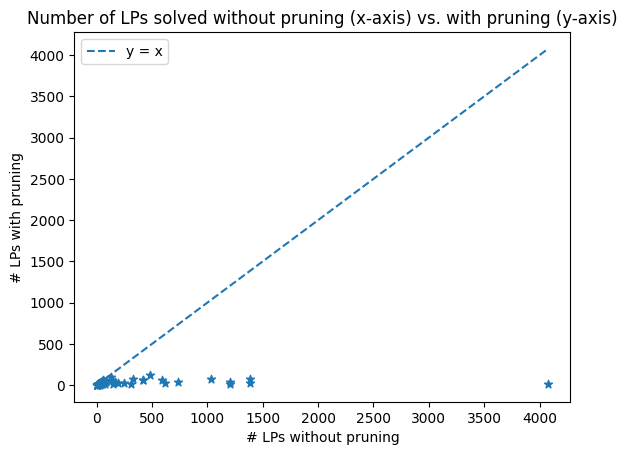

In [14]:
from matplotlib import pyplot as plt
import numpy as np 
plt.scatter(bb_without_pruning, bb_with_pruning, marker='*')
x = np.linspace(min(bb_with_pruning), max(bb_without_pruning), 400)
plt.plot(x, x, '--',label='y = x')
plt.xlabel('# LPs without pruning')
plt.ylabel('# LPs with pruning')
plt.legend()
plt.title('Number of LPs solved without pruning (x-axis) vs. with pruning (y-axis)')
plt.show()